# 05. 사용자 행동 군집화
이용 패턴 기반으로 사용자를 그룹화합니다.

In [1]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.data_loader import load_processed, save_processed
from src.feature_engineering import add_user_features, build_trip_features
from src.evaluation import plot_cluster_profiles
print("\u2705 준비 완료")

✅ 준비 완료


## 1. 데이터 및 피처 준비

In [2]:
df = load_processed("rentals_clean")
df = add_user_features(df)
df = build_trip_features(df)

# 군집화에 사용할 수치 피처
df["hour"]       = df["rent_dt"].dt.hour
df["dow"]        = df["rent_dt"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# bike_type_enc 제거: 전기자전거 여부만으로 클러스터가 분리되는 현상 방지
# → 실제 이용 행동 패턴(시간, 거리, 요일)으로만 군집화
CLUSTER_FEATS = ["use_min", "use_m", "speed_kmh", "hour", "dow", "is_weekend", "gender_enc"]

# age 추가 (있으면)
if "age" in df.columns:
    CLUSTER_FEATS.append("age")

df_cl = df[CLUSTER_FEATS].dropna()
print(f"군집화 데이터: {len(df_cl):,}행")
print(f"피처: {CLUSTER_FEATS}")

# 샘플링 (메모리 절약)
sample_n = min(100_000, len(df_cl))
df_sample = df_cl.sample(n=sample_n, random_state=42).reset_index(drop=True)

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)
print(f"\n정규화 완료: {X_scaled.shape}")

📂 Loaded rentals_clean.parquet → shape: (8559939, 27)


군집화 데이터: 6,600,060행
피처: ['use_min', 'use_m', 'speed_kmh', 'hour', 'dow', 'is_weekend', 'gender_enc', 'age']

정규화 완료: (100000, 8)


## 2. 최적 클러스터 수 탐색 (Elbow + Silhouette)

k=2  inertia=640965  silhouette=0.2675


k=3  inertia=552301  silhouette=0.2736


k=4  inertia=495920  silhouette=0.1857


k=5  inertia=452813  silhouette=0.2010


k=6  inertia=416450  silhouette=0.1912


k=7  inertia=389579  silhouette=0.1863


k=8  inertia=372255  silhouette=0.1750


k=9  inertia=357280  silhouette=0.1712


k=10  inertia=343650  silhouette=0.1733


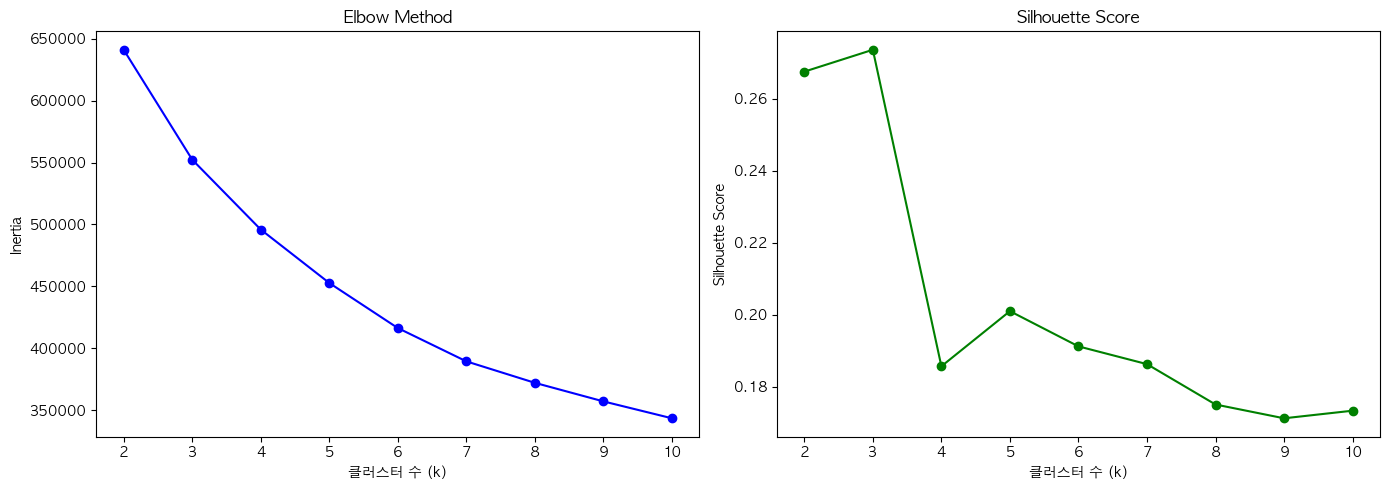


✅ 최적 k: 3 (Silhouette 최고)


In [3]:
inertias   = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, "bo-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("클러스터 수 (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, sil_scores, "go-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("클러스터 수 (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../reports/figures/kmeans_selection.png", dpi=150)
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"\n\u2705 최적 k: {best_k} (Silhouette 최고)")

## 3. K-Means 클러스터링

In [4]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_sample["cluster"] = labels

print(f"클러스터별 데이터 수:")
print(df_sample["cluster"].value_counts().sort_index())

클러스터별 데이터 수:
cluster
0    11480
1    21154
2    67366
Name: count, dtype: int64


## 4. 클러스터 프로파일 분석

In [5]:
profile = df_sample.groupby("cluster")[CLUSTER_FEATS].mean().round(2)
print("클러스터별 평균 프로파일:")
print(profile.T)

클러스터별 평균 프로파일:
cluster           0        1        2
use_min       73.05    16.38    11.51
use_m       6455.55  1841.87  1464.07
speed_kmh      6.35     8.18     8.81
hour          14.56    13.73    13.48
dow            2.70     5.48     2.04
is_weekend     0.15     1.00     0.00
gender_enc     0.16     0.17     0.18
age           40.68    36.06    37.00


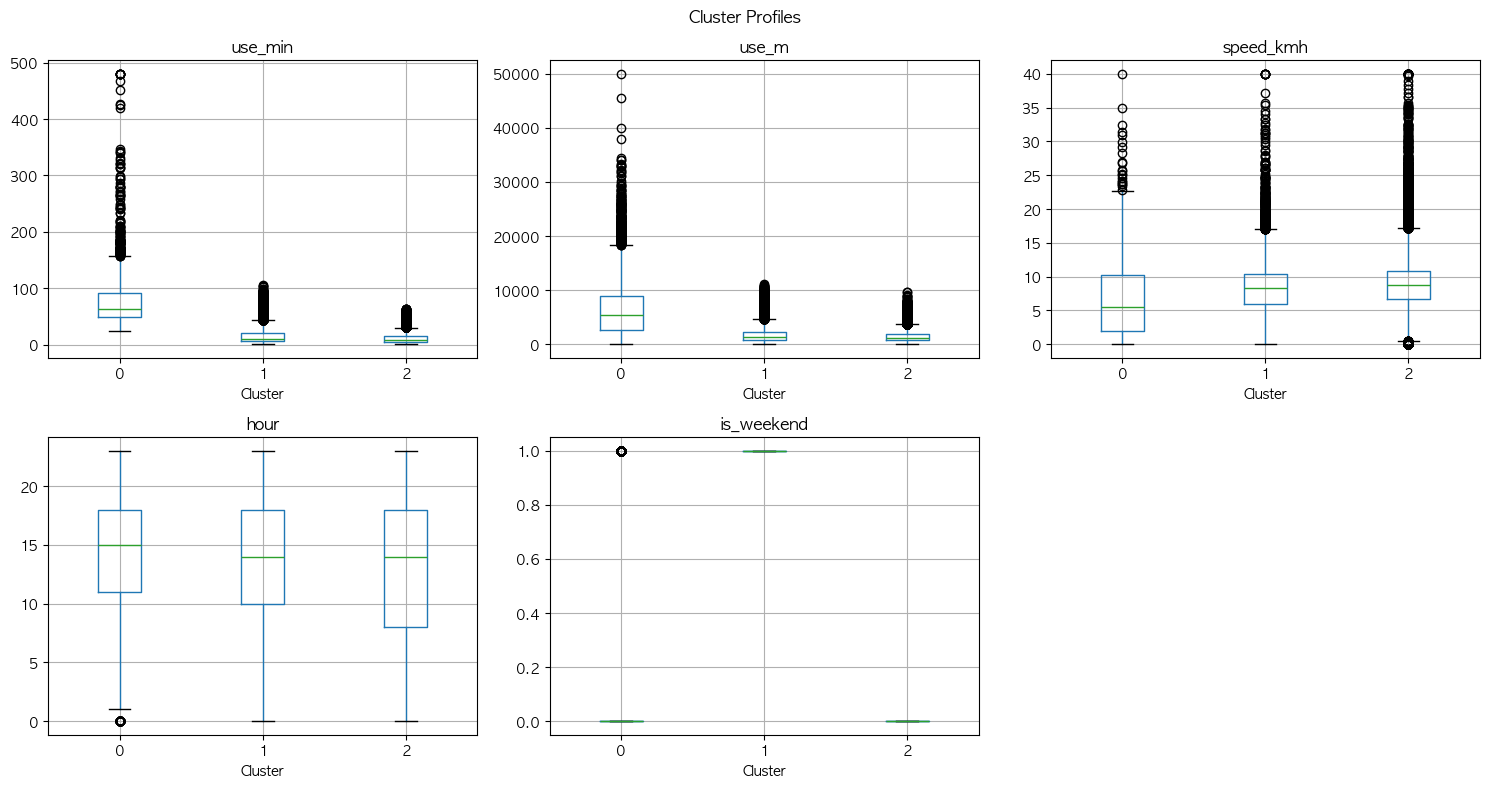

In [6]:
plot_cluster_profiles(
    df_sample,
    feature_cols=["use_min", "use_m", "speed_kmh", "hour", "is_weekend"],
    cluster_col="cluster",
    save_name="cluster_profiles"
)

## 5. PCA 기반 2D 시각화

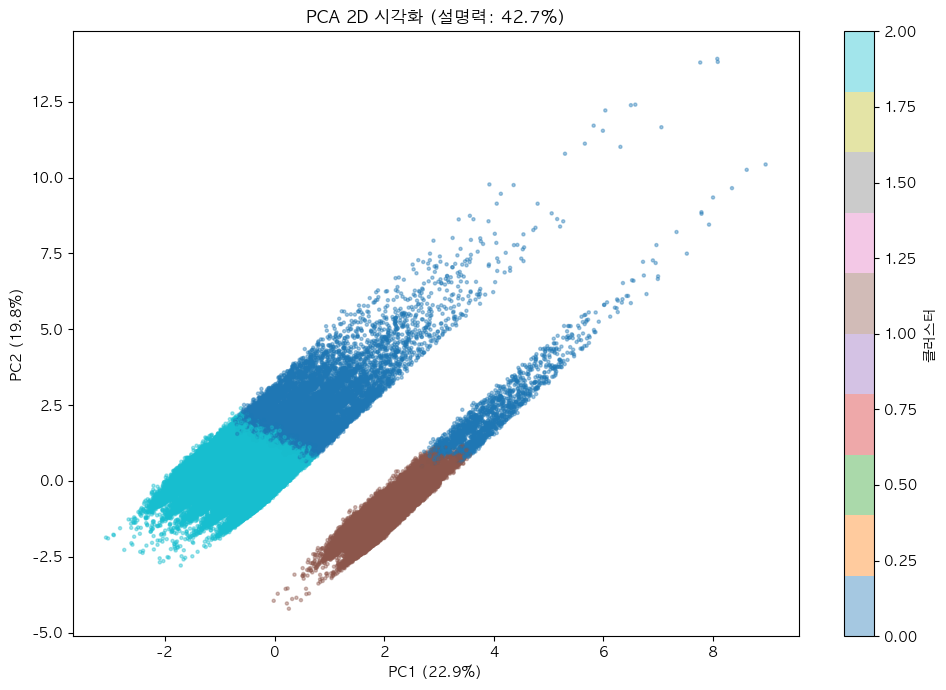

In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=labels, cmap="tab10", alpha=0.4, s=5)
plt.colorbar(scatter, label="클러스터")
plt.title(f"PCA 2D 시각화 (설명력: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.savefig("../reports/figures/pca_clusters.png", dpi=150)
plt.show()

## 6. 클러스터 특성 기반 이름 부여

클러스터 0 → 일반형_0
클러스터 1 → 레저형(주말)
클러스터 2 → 단거리형


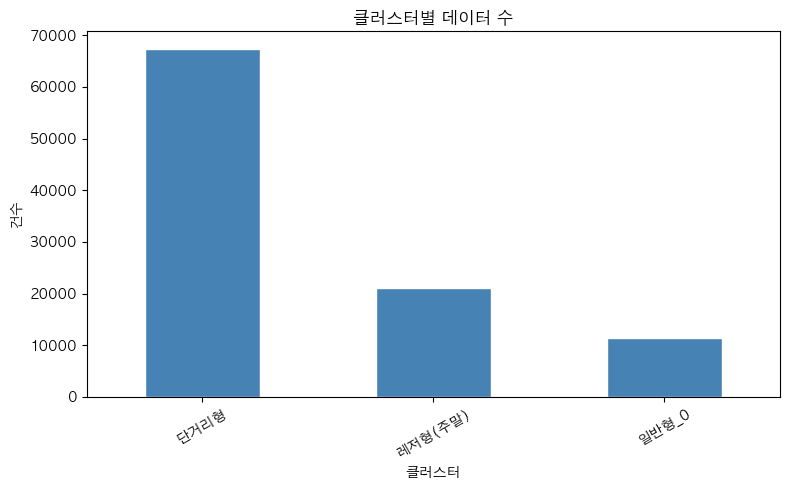

In [8]:
# 프로파일을 기반으로 클러스터에 의미 있는 이름 부여
cluster_names = {}
for c in range(best_k):
    cdf = profile.loc[c]
    if cdf.get("is_weekend", 0) > 0.6:
        name = "레저형(주말)"
    elif cdf.get("hour", 12) in range(7, 10) or cdf.get("hour", 12) in range(17, 20):
        name = "출퇴근형"
    elif cdf.get("use_min", 30) < 15:
        name = "단거리형"
    elif cdf.get("age", 30) > 50:
        name = "시니어형"
    else:
        name = f"일반형_{c}"
    cluster_names[c] = name
    print(f"클러스터 {c} \u2192 {name}")

df_sample["cluster_name"] = df_sample["cluster"].map(cluster_names)

plt.figure(figsize=(8, 5))
df_sample["cluster_name"].value_counts().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("클러스터별 데이터 수")
plt.xlabel("클러스터")
plt.ylabel("건수")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_names.png", dpi=150)
plt.show()

## 7. 저장

In [9]:
# 클러스터 결과 저장
save_processed(df_sample, "user_clusters")

# 모델 저장
model_dir = Path("../models/clustering")
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(kmeans, model_dir / f"kmeans_k{best_k}.pkl")
joblib.dump(scaler, model_dir / "cluster_scaler.pkl")

print(f"\u2705 KMeans 모델 저장: models/clustering/kmeans_k{{best_k}}.pkl")
print(f"\u2705 클러스터 데이터 저장: data/processed/user_clusters.parquet")

💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/user_clusters.parquet  (1.8 MB)


✅ KMeans 모델 저장: models/clustering/kmeans_k{best_k}.pkl
✅ 클러스터 데이터 저장: data/processed/user_clusters.parquet
